# Analisis robusto de datos existentes

## Resumen ejecutivo

Este cuaderno analiza exclusivamente artefactos ya capturados. No ejecuta adquisicion en vivo, no accede a hardware y no presupone que el montaje experimental siga disponible. El objetivo cientifico es separar afirmaciones defendibles de extrapolaciones no soportadas.

La conclusion central es conservadora: los datos de camara0 permiten estudiar detectabilidad agregada, cuantizacion temporal por cuadro y reconstruccion estadistica por seleccion/promedio; no permiten fotometria calibrada, temporizacion sub-cuadro ni reconstruccion de intensidad pulso a pulso.

| Area | Conclusion defendible | Confianza |
|---|---|---|
| Resolucion de intensidad | Los barridos validos agregados por duty muestran ausencia de detecciones hasta duty 3 y detecciones repetidas desde duty 4. La transicion es un intervalo practico, no un umbral fisico puntual. | Moderada |
| Resolucion temporal | La camara opera cerca de 30 FPS; por lo tanto, el periodo de cuadro impone una cuantizacion de aproximadamente 33 ms y una incertidumbre natural de medio cuadro. | Fuerte para limites, debil para temporizacion fina |
| Reconstruccion estadistica | Los artefactos validos de camara0 muestran alta cobertura de coincidencias en corridas seleccionadas. Esto respalda promedios estadisticos, no imagen de alta velocidad cuadro a cuadro. | Moderada |
| Apilado tipo astrofotografia | El promedio de cuadros puede mejorar la relacion senal-ruido bajo supuestos de ruido independiente y senal estacionaria. La analogia es util, pero no reemplaza calibracion fotometrica. | Moderada como analogia |

## Objetivo y alcance cientifico

El analisis busca responder cuatro preguntas acotadas:

1. Que probabilidad de deteccion agregada se observa para cada duty del LED?
2. Que limites temporales impone la camara por su frecuencia de cuadros?
3. Que incertidumbre introducen la seleccion de corridas, el umbral de deteccion y la variabilidad entre replicas?
4. Que conclusiones pueden sostenerse sin afirmar capacidades que los datos no miden directamente?

## Exclusiones obligatorias

- La camara cientificamente correcta es el indice 0. No se usa el indice 2 para afirmaciones cientificas.
- Se excluye `new-camera-mount-20260526-phase4` porque uso la camara incorrecta.
- Las campanas validas de camara0 para reconstruccion son `new-camera-mount-20260526-camera0` y `new-camera-mount-20260526-camera0-extra10`.
- No se usa `camera0_intensity_per_pulse.csv`: los barridos nuevos disponibles son agregados por duty, no datos por pulso.
- No se afirma fotometria calibrada ni temporizacion sub-cuadro.

In [1]:
from pathlib import Path
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from scipy.stats import beta as beta_distribution
except Exception:
    beta_distribution = None

try:
    from IPython.display import Image, Markdown, display
except Exception:
    Image = Markdown = display = None

ROOT = Path.cwd()
if not (ROOT / 'data').exists() and (ROOT.parent / 'data').exists():
    ROOT = ROOT.parent

VALID_CAMPAIGNS = [
    'new-camera-mount-20260526-camera0',
    'new-camera-mount-20260526-camera0-extra10',
]
VALID_SWEEPS = [
    ROOT / 'data/webcam/led_intensity_sweep_20260526_184256.csv',
    ROOT / 'data/webcam/led_intensity_sweep_20260526_185645.csv',
    ROOT / 'data/webcam/led_intensity_sweep_20260526_191013.csv',
]
DERIVED = ROOT / 'data/derived'
STUDIES = DERIVED / 'studies'

def require(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)
    return path

def read_csv(path):
    return pd.read_csv(require(path))

def wilson_interval(k, n, z=1.959963984540054):
    if n <= 0:
        return (np.nan, np.nan, np.nan)
    p = k / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    half = z * math.sqrt((p * (1 - p) / n) + (z**2 / (4 * n**2))) / denom
    return p, max(0.0, center - half), min(1.0, center + half)

def jeffreys_interval(k, n, alpha=0.05):
    if n <= 0 or beta_distribution is None:
        return (np.nan, np.nan)
    return (
        beta_distribution.ppf(alpha / 2, k + 0.5, n - k + 0.5),
        beta_distribution.ppf(1 - alpha / 2, k + 0.5, n - k + 0.5),
    )

def interpolate_duty_for_probability(curve, target):
    ordered = curve.sort_values('duty')
    previous = None
    for row in ordered.itertuples(index=False):
        current = (float(row.duty), float(row.p_hat))
        if current[1] >= target:
            if previous is None:
                return current[0]
            x0, y0 = previous
            x1, y1 = current
            if y1 == y0:
                return current[0]
            return x0 + (target - y0) * (x1 - x0) / (y1 - y0)
        previous = current
    return np.nan

def frame_period_ms_from_fps(fps):
    return 1000.0 / fps if fps and fps > 0 else np.nan

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 160)
print(f'Raiz del repositorio: {ROOT}')

Raiz del repositorio: /home/juanm/SensorArray-for-laser-Lissajous-curves


## Procedencia de datos y criterio de exclusion

La procedencia forma parte del analisis. Que un archivo exista en el repositorio no basta: debe pertenecer a las campanas validas de camara0 o al conjunto explicito de barridos de intensidad aceptados.

La tabla siguiente documenta los artefactos efectivamente cargados. Esta trazabilidad evita mezclar resultados de montajes o camaras incompatibles.

In [2]:
provenance_rows = []
for path in VALID_SWEEPS:
    df = read_csv(path)
    provenance_rows.append({
        'artefacto': str(path.relative_to(ROOT)),
        'rol': 'barrido de intensidad valido agregado',
        'filas': len(df),
        'columnas': ', '.join(df.columns),
    })

for campaign in VALID_CAMPAIGNS:
    for rel in [
        f'data/derived/studies-camera0/{campaign}/dual_random_train_runs.csv',
        f'data/derived/studies-camera0/{campaign}/dual_random_train_overall.csv',
        f'data/derived/reconstruction-camera0/{campaign}/reconstruction_statistics.csv',
        f'data/derived/reconstruction-camera0/{campaign}/threshold_sensitivity.csv',
        f'data/derived/reconstruction-camera0/{campaign}/best_dual_run_selection.csv',
    ]:
        path = ROOT / rel
        if path.exists():
            df = pd.read_csv(path)
            provenance_rows.append({
                'artefacto': rel,
                'rol': f'artefacto valido de camara0: {campaign}',
                'filas': len(df),
                'columnas': ', '.join(df.columns),
            })

provenance = pd.DataFrame(provenance_rows)
provenance

,artefacto,rol,filas,columnas
0,data/webcam/led_intensity_sweep_20260526_18425...,barrido de intensidad valido agregado,17,"duty, intensity_percent, detection_events, det..."
1,data/webcam/led_intensity_sweep_20260526_18564...,barrido de intensidad valido agregado,17,"duty, intensity_percent, detection_events, det..."
2,data/webcam/led_intensity_sweep_20260526_19101...,barrido de intensidad valido agregado,17,"duty, intensity_percent, detection_events, det..."
3,data/derived/studies-camera0/new-camera-mount-...,artefacto valido de camara0: new-camera-mount-...,10,"run_id, variant, campaign_id, mount_context, r..."
4,data/derived/studies-camera0/new-camera-mount-...,artefacto valido de camara0: new-camera-mount-...,2,"subset, run_count, mean_windowed_success_rate,..."
5,data/derived/reconstruction-camera0/new-camera...,artefacto valido de camara0: new-camera-mount-...,2,"group_type, group_id, run_id, variant, phase_o..."
6,data/derived/reconstruction-camera0/new-camera...,artefacto valido de camara0: new-camera-mount-...,2,"run_id, threshold_delta_fraction, covered_puls..."
7,data/derived/reconstruction-camera0/new-camera...,artefacto valido de camara0: new-camera-mount-...,10,"run_id, variant, campaign_id, mount_context, r..."
8,data/derived/studies-camera0/new-camera-mount-...,artefacto valido de camara0: new-camera-mount-...,10,"run_id, variant, campaign_id, mount_context, r..."
9,data/derived/studies-camera0/new-camera-mount-...,artefacto valido de camara0: new-camera-mount-...,2,"subset, run_count, mean_windowed_success_rate,..."


## Modelo de deteccion binomial para intensidad

### Variable aleatoria y estimador

Para un duty fijo, se modela cada pulso esperado como un ensayo de Bernoulli:

$$X_i \sim \mathrm{Bernoulli}(p), \qquad i=1,\dots,n$$

donde `p` es la probabilidad de que el sistema registre una deteccion bajo las condiciones agregadas de ese duty. Si `k` pulsos fueron detectados dentro de `n` pulsos esperados, el estimador puntual es:

$$\hat p = \frac{k}{n}$$

En este cuaderno se usa `bounded_detected_total` como `k` y `expected_total_pulses` como `n`.

### Intervalo de Wilson

El intervalo de Wilson al 95% se calcula como:

$$
\frac{\hat p + z^2/(2n)}{1+z^2/n}
\pm
\frac{z}{1+z^2/n}
\sqrt{\frac{\hat p(1-\hat p)}{n}+\frac{z^2}{4n^2}}
$$

Es apropiado cuando se desea un intervalo frecuentista estable cerca de los bordes `p=0` y `p=1`, evitando los problemas del intervalo normal simetrico.

### Intervalo de Jeffreys

El intervalo de Jeffreys usa la posterior bayesiana con prior no informativa Beta(1/2, 1/2):

$$p \mid k,n \sim \mathrm{Beta}(k+1/2, n-k+1/2)$$

El intervalo creible al 95% se obtiene de los cuantiles 2.5% y 97.5% de esa distribucion. Es especialmente util para contrastar sensibilidad en casos extremos, por ejemplo `k=0` o `k=n`.

### Supuestos operativos

- Las filas disponibles son agregadas por duty; no son observaciones pulso a pulso.
- Las replicas comparten montaje, exposicion y procesamiento, por lo que la independencia es aproximada.
- El umbral de detectabilidad se reporta como intervalo: ultimo duty sin detecciones y primer duty con detecciones.
- `duty50` y `duty90` solo son identificables si la curva observada alcanza probabilidades 0.50 y 0.90. Si el maximo observado queda por debajo, no se estiman.

In [3]:
intensity_by_duty = read_csv(STUDIES / 'webcam_intensity_by_duty.csv')
intensity_observations = read_csv(STUDIES / 'webcam_intensity_observations.csv')

intervals = intensity_by_duty.apply(
    lambda row: wilson_interval(row['bounded_detected_total'], row['expected_total_pulses']),
    axis=1,
    result_type='expand',
)
intervals.columns = ['p_hat', 'wilson_low', 'wilson_high']
jeffreys = intensity_by_duty.apply(
    lambda row: jeffreys_interval(row['bounded_detected_total'], row['expected_total_pulses']),
    axis=1,
    result_type='expand',
)
jeffreys.columns = ['jeffreys_low', 'jeffreys_high']
intensity_intervals = pd.concat([intensity_by_duty, intervals, jeffreys], axis=1)

zero_duties = intensity_intervals.loc[intensity_intervals['bounded_detected_total'] == 0, 'duty']
nonzero_duties = intensity_intervals.loc[intensity_intervals['bounded_detected_total'] > 0, 'duty']
threshold_bracket = {
    'ultimo_duty_sin_deteccion': int(zero_duties.max()) if len(zero_duties) else None,
    'primer_duty_con_deteccion': int(nonzero_duties.min()) if len(nonzero_duties) else None,
}

display(intensity_intervals[[
    'duty', 'replicates', 'bounded_detected_total', 'expected_total_pulses',
    'p_hat', 'wilson_low', 'wilson_high', 'jeffreys_low', 'jeffreys_high', 'mean_detected_frames'
]].rename(columns={
    'replicates': 'replicas',
    'bounded_detected_total': 'detecciones_acotadas_totales',
    'expected_total_pulses': 'pulsos_esperados_totales',
    'p_hat': 'p_estimado',
    'wilson_low': 'wilson_inf',
    'wilson_high': 'wilson_sup',
    'jeffreys_low': 'jeffreys_inf',
    'jeffreys_high': 'jeffreys_sup',
    'mean_detected_frames': 'cuadros_detectados_medios',
}))
threshold_bracket

,duty,replicas,detecciones_acotadas_totales,pulsos_esperados_totales,p_estimado,wilson_inf,wilson_sup,jeffreys_inf,jeffreys_sup,cuadros_detectados_medios
0,0,3,0,180,0.000000,0.000000,0.020895,0.000003,0.013839,0.000
1,1,3,0,180,0.000000,0.000000,0.020895,0.000003,0.013839,0.000
2,2,3,0,180,0.000000,0.000000,0.020895,0.000003,0.013839,0.000
3,3,3,0,180,0.000000,0.000000,0.020895,0.000003,0.013839,0.000
4,4,3,14,180,0.077778,0.046893,0.126307,0.045275,0.123702,12.333
5,5,3,21,180,0.116667,0.077586,0.171768,0.075942,0.169591,41.667
6,6,3,21,180,0.116667,0.077586,0.171768,0.075942,0.169591,41.667
7,7,3,22,180,0.122222,0.082115,0.178117,0.080475,0.175993,42.333
8,8,3,24,180,0.133333,0.091263,0.190727,0.089634,0.188705,48.000
9,10,3,21,180,0.116667,0.077586,0.171768,0.075942,0.169591,42.000


{'ultimo_duty_sin_deteccion': 3, 'primer_duty_con_deteccion': 4}

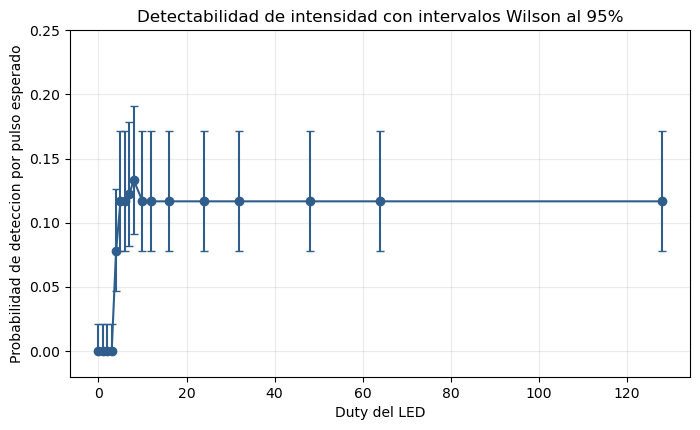

In [4]:
fig, ax = plt.subplots(figsize=(8, 4.5))
x = intensity_intervals['duty'].to_numpy()
y = intensity_intervals['p_hat'].to_numpy()
yerr = np.vstack([
    np.maximum(0, y - intensity_intervals['wilson_low'].to_numpy()),
    np.maximum(0, intensity_intervals['wilson_high'].to_numpy() - y),
])
ax.errorbar(x, y, yerr=yerr, fmt='o-', capsize=3, color='#2f5d8c')
ax.set_xlabel('Duty del LED')
ax.set_ylabel('Probabilidad de deteccion por pulso esperado')
ax.set_title('Detectabilidad de intensidad con intervalos Wilson al 95%')
ax.grid(True, alpha=0.25)
ax.set_ylim(-0.02, min(1.0, max(0.25, float(intensity_intervals['wilson_high'].max()) + 0.05)))
plt.show()

### Comparacion Wilson vs. Jeffreys

Wilson y Jeffreys deberian coincidir de manera aproximada cuando `n` es razonable y `p` no esta en los extremos. La comparacion es importante aqui porque hay varios casos con `k=0`, precisamente donde un intervalo normal simple seria enganoso.

,duty,p_estimado,wilson_inf,wilson_sup,ancho_wilson,jeffreys_inf,jeffreys_sup,ancho_jeffreys
0,0,0.000000,0.000000,0.020895,0.020895,0.000003,0.013839,0.013836
1,1,0.000000,0.000000,0.020895,0.020895,0.000003,0.013839,0.013836
2,2,0.000000,0.000000,0.020895,0.020895,0.000003,0.013839,0.013836
3,3,0.000000,0.000000,0.020895,0.020895,0.000003,0.013839,0.013836
4,4,0.077778,0.046893,0.126307,0.079414,0.045275,0.123702,0.078427
5,5,0.116667,0.077586,0.171768,0.094182,0.075942,0.169591,0.093648
6,6,0.116667,0.077586,0.171768,0.094182,0.075942,0.169591,0.093648
7,7,0.122222,0.082115,0.178117,0.096001,0.080475,0.175993,0.095517
8,8,0.133333,0.091263,0.190727,0.099464,0.089634,0.188705,0.099072
9,10,0.116667,0.077586,0.171768,0.094182,0.075942,0.169591,0.093648


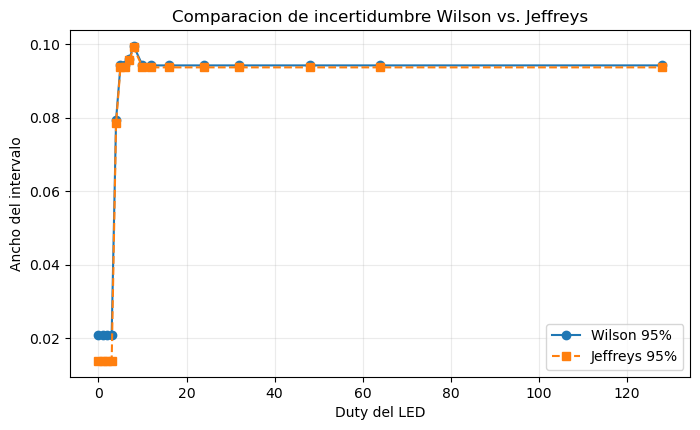

In [5]:
interval_comparison = intensity_intervals.assign(
    wilson_width=intensity_intervals['wilson_high'] - intensity_intervals['wilson_low'],
    jeffreys_width=intensity_intervals['jeffreys_high'] - intensity_intervals['jeffreys_low'],
)

display(interval_comparison[[
    'duty', 'p_hat', 'wilson_low', 'wilson_high', 'wilson_width',
    'jeffreys_low', 'jeffreys_high', 'jeffreys_width'
]].rename(columns={
    'p_hat': 'p_estimado',
    'wilson_low': 'wilson_inf',
    'wilson_high': 'wilson_sup',
    'wilson_width': 'ancho_wilson',
    'jeffreys_low': 'jeffreys_inf',
    'jeffreys_high': 'jeffreys_sup',
    'jeffreys_width': 'ancho_jeffreys',
}))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(interval_comparison['duty'], interval_comparison['wilson_width'], 'o-', label='Wilson 95%')
ax.plot(interval_comparison['duty'], interval_comparison['jeffreys_width'], 's--', label='Jeffreys 95%')
ax.set_xlabel('Duty del LED')
ax.set_ylabel('Ancho del intervalo')
ax.set_title('Comparacion de incertidumbre Wilson vs. Jeffreys')
ax.grid(True, alpha=0.25)
ax.legend()
plt.show()

### Variabilidad entre replicas y estabilidad del umbral

La curva media por duty puede ocultar variabilidad experimental. Por eso se revisan las replicas una por una y se resume el intervalo de primera deteccion por corrida. La evidencia sigue siendo agregada por duty; no se convierte en evidencia por pulso.

In [6]:
replicate_variability = intensity_observations.groupby('duty').agg(
    replicates=('source_run', 'nunique'),
    mean_probability=('detection_probability', 'mean'),
    std_probability=('detection_probability', 'std'),
    min_probability=('detection_probability', 'min'),
    max_probability=('detection_probability', 'max'),
    total_expected_pulses=('expected_pulses', 'sum'),
    total_bounded_detected=('bounded_detected_pulses', 'sum'),
).reset_index()
replicate_variability['std_probability'] = replicate_variability['std_probability'].fillna(0.0)

threshold_by_run = []
for source_run, run_df in intensity_observations.groupby('source_run'):
    zero = run_df.loc[run_df['bounded_detected_pulses'] == 0, 'duty']
    nonzero = run_df.loc[run_df['bounded_detected_pulses'] > 0, 'duty']
    threshold_by_run.append({
        'corrida_fuente': source_run,
        'ultimo_duty_sin_deteccion': int(zero.max()) if len(zero) else np.nan,
        'primer_duty_con_deteccion': int(nonzero.min()) if len(nonzero) else np.nan,
    })
threshold_by_run = pd.DataFrame(threshold_by_run)
threshold_stability = threshold_by_run[['ultimo_duty_sin_deteccion', 'primer_duty_con_deteccion']].agg(['min', 'median', 'max'])

max_supported_p = float(intensity_intervals['p_hat'].max())
duty_targets = pd.DataFrame([
    {
        'probabilidad_objetivo': target,
        'duty_estimado': interpolate_duty_for_probability(intensity_intervals, target),
        'estado': 'estimable por interpolacion lineal' if max_supported_p >= target else f'no estimable: la p agregada maxima observada es {max_supported_p:.3f}',
    }
    for target in [0.10, 0.50, 0.90]
])

display(replicate_variability.rename(columns={
    'replicates': 'replicas',
    'mean_probability': 'probabilidad_media',
    'std_probability': 'desvio_estandar_probabilidad',
    'min_probability': 'probabilidad_minima',
    'max_probability': 'probabilidad_maxima',
    'total_expected_pulses': 'pulsos_esperados_totales',
    'total_bounded_detected': 'detecciones_acotadas_totales',
}))
display(threshold_by_run)
display(threshold_stability)
display(duty_targets)

,duty,replicas,probabilidad_media,desvio_estandar_probabilidad,probabilidad_minima,probabilidad_maxima,pulsos_esperados_totales,detecciones_acotadas_totales
0,0,3,0.000000,0.000000,0.000000,0.000000,180,0
1,1,3,0.000000,0.000000,0.000000,0.000000,180,0
2,2,3,0.000000,0.000000,0.000000,0.000000,180,0
3,3,3,0.000000,0.000000,0.000000,0.000000,180,0
4,4,3,0.077778,0.034695,0.050000,0.116667,180,14
5,5,3,0.116667,0.000000,0.116667,0.116667,180,21
6,6,3,0.116667,0.000000,0.116667,0.116667,180,21
7,7,3,0.122222,0.009622,0.116667,0.133333,180,22
8,8,3,0.133334,0.028868,0.116667,0.166667,180,24
9,10,3,0.116667,0.000000,0.116667,0.116667,180,21


,corrida_fuente,ultimo_duty_sin_deteccion,primer_duty_con_deteccion
0,led_intensity_sweep_20260526_184256,3,4
1,led_intensity_sweep_20260526_185645,3,4
2,led_intensity_sweep_20260526_191013,3,4


,ultimo_duty_sin_deteccion,primer_duty_con_deteccion
min,3.0,4.0
median,3.0,4.0
max,3.0,4.0


,probabilidad_objetivo,duty_estimado,estado
0,0.1,4.571429,estimable por interpolacion lineal
1,0.5,NaN,no estimable: la p agregada maxima observada e...
2,0.9,NaN,no estimable: la p agregada maxima observada e...


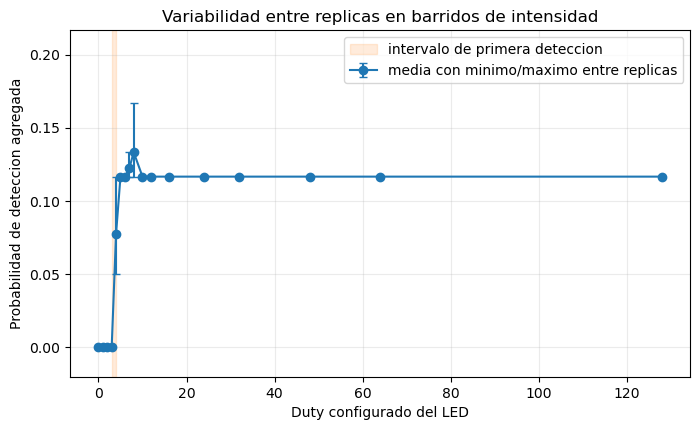

In [7]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.errorbar(
    replicate_variability['duty'],
    replicate_variability['mean_probability'],
    yerr=[
        replicate_variability['mean_probability'] - replicate_variability['min_probability'],
        replicate_variability['max_probability'] - replicate_variability['mean_probability'],
    ],
    fmt='o-',
    capsize=3,
    label='media con minimo/maximo entre replicas',
)
ax.axvspan(
    threshold_bracket['ultimo_duty_sin_deteccion'],
    threshold_bracket['primer_duty_con_deteccion'],
    color='tab:orange',
    alpha=0.15,
    label='intervalo de primera deteccion',
)
ax.set_xlabel('Duty configurado del LED')
ax.set_ylabel('Probabilidad de deteccion agregada')
ax.set_title('Variabilidad entre replicas en barridos de intensidad')
ax.set_ylim(-0.02, max(0.2, replicate_variability['max_probability'].max() + 0.05))
ax.grid(True, alpha=0.25)
ax.legend()
plt.show()

### Contexto de duracion y exposicion

Las tablas de duracion y exposicion se reutilizan como contexto cualitativo. La mayoria de las condiciones tiene una sola replica y tres pulsos esperados, de modo que los intervalos son amplios por construccion. La lectura correcta es de plausibilidad experimental, no de calibracion fina.

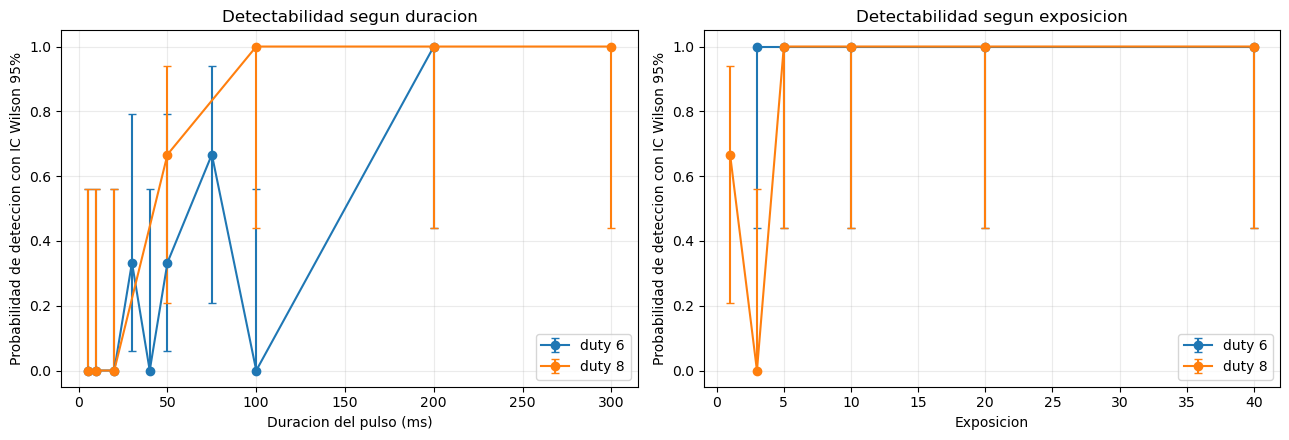

,duty,duration_ms,replicates,mean_detection_probability,median_detection_probability,detected_total_events,bounded_detected_total,expected_total_pulses,p_hat,wilson_low,wilson_high
0,6,5,1,0.000000,0.000000,0,0,3,0.000000,5.551115e-17,0.561497
1,6,10,1,0.000000,0.000000,0,0,3,0.000000,5.551115e-17,0.561497
2,6,20,1,0.000000,0.000000,0,0,3,0.000000,5.551115e-17,0.561497
3,6,30,1,0.333333,0.333333,1,1,3,0.333333,6.149194e-02,0.792340
4,6,40,1,0.000000,0.000000,0,0,3,0.000000,5.551115e-17,0.561497
5,6,50,1,0.333333,0.333333,1,1,3,0.333333,6.149194e-02,0.792340
6,6,75,1,0.666667,0.666667,2,2,3,0.666667,2.076596e-01,0.938508
7,6,100,1,0.000000,0.000000,0,0,3,0.000000,5.551115e-17,0.561497
8,6,200,1,1.000000,1.000000,3,3,3,1.000000,4.385030e-01,1.000000
9,8,5,1,0.000000,0.000000,0,0,3,0.000000,5.551115e-17,0.561497


,duty,exposure,replicates,mean_detection_probability,median_detection_probability,detected_total_events,bounded_detected_total,expected_total_pulses,p_hat,wilson_low,wilson_high
0,6,3.0,1,1.000000,1.000000,3,3,3,1.000000,4.385030e-01,1.000000
1,6,5.0,1,1.000000,1.000000,6,3,3,1.000000,4.385030e-01,1.000000
2,6,10.0,1,1.000000,1.000000,4,3,3,1.000000,4.385030e-01,1.000000
3,6,20.0,1,1.000000,1.000000,3,3,3,1.000000,4.385030e-01,1.000000
4,6,40.0,1,1.000000,1.000000,3,3,3,1.000000,4.385030e-01,1.000000
5,8,1.0,1,0.666667,0.666667,2,2,3,0.666667,2.076596e-01,0.938508
6,8,3.0,1,0.000000,0.000000,0,0,3,0.000000,5.551115e-17,0.561497
7,8,5.0,1,1.000000,1.000000,3,3,3,1.000000,4.385030e-01,1.000000
8,8,10.0,1,1.000000,1.000000,3,3,3,1.000000,4.385030e-01,1.000000
9,8,20.0,1,1.000000,1.000000,3,3,3,1.000000,4.385030e-01,1.000000


In [8]:
parameter_tables = {}
for name, file_name, x_col in [
    ('duracion', 'webcam_parameter_by_duration.csv', 'duration_ms'),
    ('exposicion', 'webcam_parameter_by_exposure.csv', 'exposure'),
]:
    path = STUDIES / file_name
    if not path.exists():
        warnings.warn(f'No existe {path}')
        continue
    table = pd.read_csv(path).copy()
    intervals = table.apply(
        lambda row: wilson_interval(row['bounded_detected_total'], row['expected_total_pulses']),
        axis=1,
        result_type='expand',
    )
    intervals.columns = ['p_hat', 'wilson_low', 'wilson_high']
    parameter_tables[name] = pd.concat([table, intervals], axis=1)

fig, axes = plt.subplots(1, len(parameter_tables), figsize=(13, 4.5), squeeze=False)
for ax, (name, table) in zip(axes[0], parameter_tables.items()):
    x_col = 'duration_ms' if name == 'duracion' else 'exposure'
    for duty, group in table.groupby('duty'):
        ax.errorbar(
            group[x_col],
            group['p_hat'],
            yerr=np.vstack([
                np.maximum(0, group['p_hat'].to_numpy() - group['wilson_low'].to_numpy()),
                np.maximum(0, group['wilson_high'].to_numpy() - group['p_hat'].to_numpy()),
            ]),
            marker='o',
            capsize=3,
            label=f'duty {duty}',
        )
    ax.set_xlabel('Duracion del pulso (ms)' if x_col == 'duration_ms' else 'Exposicion')
    ax.set_ylabel('Probabilidad de deteccion con IC Wilson 95%')
    ax.set_title(f'Detectabilidad segun {name}')
    ax.grid(True, alpha=0.25)
    ax.legend()
plt.tight_layout()
plt.show()

if 'duracion' in parameter_tables:
    display(parameter_tables['duracion'])
if 'exposicion' in parameter_tables:
    display(parameter_tables['exposicion'])

### Advertencia sobre resolucion de intensidad

La curva se aplana cerca del mismo conteo acotado para muchos duties. Esa meseta indica que la respuesta esta limitada por cadencia de cuadros, definicion de evento, exposicion y saturacion/recorte del procedimiento de conteo. Por lo tanto:

- `duty10` queda apenas acotado por interpolacion lineal sobre una curva agregada.
- `duty50` y `duty90` no son identificables con estos datos porque la probabilidad agregada maxima observada es mucho menor que 0.50.
- La resolucion de intensidad defendible es un bracket de primera detectabilidad, no una escala fotometrica calibrada.

## Resolucion temporal

La afirmacion temporal mas fuerte es un limite instrumental. Para una camara con frecuencia de cuadros `FPS`, el periodo de cuadro es:

$$T_f = \frac{1000}{FPS}\;\mathrm{ms}$$

Si un evento se observa solo a nivel de cuadro, la localizacion temporal dentro del cuadro tiene una incertidumbre natural de orden:

$$u_f \approx \frac{T_f}{2}$$

Esto equivale a una cuantizacion temporal: dos eventos separados por menos de un periodo de cuadro pueden caer en el mismo cuadro o en cuadros adyacentes dependiendo de la fase relativa. La interpretacion tipo Nyquist tambien es conservadora: no se deben afirmar fenomenos temporales por encima de la resolucion de muestreo de cuadros sin una fuente de temporizacion independiente.

In [9]:
fps = pd.to_numeric(intensity_observations['measured_fps'], errors='coerce').dropna()
fps_summary = pd.Series({
    'observaciones': len(fps),
    'fps_medio': fps.mean(),
    'fps_desvio_estandar': fps.std(ddof=1),
    'fps_minimo': fps.min(),
    'fps_maximo': fps.max(),
    'periodo_cuadro_ms': frame_period_ms_from_fps(fps.mean()),
    'medio_periodo_cuadro_ms': frame_period_ms_from_fps(fps.mean()) / 2,
})
fps_summary

observaciones              51.000000
fps_medio                  29.875294
fps_desvio_estandar         0.098861
fps_minimo                 29.800000
fps_maximo                 30.390000
periodo_cuadro_ms          33.472474
medio_periodo_cuadro_ms    16.736237
dtype: float64

In [10]:
run_tables = []
for campaign in VALID_CAMPAIGNS:
    path = ROOT / f'data/derived/studies-camera0/{campaign}/dual_random_train_runs.csv'
    if path.exists():
        df = pd.read_csv(path)
        df['campaign'] = campaign
        run_tables.append(df)

camera0_runs = pd.concat(run_tables, ignore_index=True) if run_tables else pd.DataFrame()
offset_summary = camera0_runs.groupby('campaign').agg(
    corridas=('run_id', 'nunique'),
    pulsos_cubiertos=('covered_pulses', 'sum'),
    coincidencias=('matched_detected', 'sum'),
    tasa_media_coincidencia=('coincidence_success_rate_windowed', 'mean'),
    desfase_medio_ms=('mean_offset_ms_windowed', 'mean'),
    desfase_std_entre_corridas_ms=('mean_offset_ms_windowed', 'std'),
).reset_index()
display(offset_summary)

,campaign,corridas,pulsos_cubiertos,coincidencias,tasa_media_coincidencia,desfase_medio_ms,desfase_std_entre_corridas_ms
0,new-camera-mount-20260526-camera0,10,600,600,1.000000,49.549639,2.486095
1,new-camera-mount-20260526-camera0-extra10,10,600,599,0.998333,49.032663,2.958249


### Propagacion de incertidumbre temporal

Cuando las fuentes de incertidumbre son independientes y se expresan como desviaciones estandar o terminos equivalentes, se combinan por raiz de suma de cuadrados:

$$u_c = \sqrt{u_1^2 + u_2^2 + \cdots + u_m^2}$$

Aqui se usa una aproximacion intervalar y conservadora: medio periodo de cuadro para la camara y medio intervalo de muestreo para el anclaje OP598 cuando esta disponible. Esta propagacion no autoriza temporizacion sub-cuadro; solo cuantifica el ancho minimo de una afirmacion temporal defendible.

In [11]:
half_frame_ms = float(fps_summary['medio_periodo_cuadro_ms'])
assumed_anchor_ms = 6.6 / 2
temporal_uncertainty = pd.DataFrame([
    {'termino': 'periodo de cuadro medio', 'valor_ms': float(fps_summary['periodo_cuadro_ms']), 'uso': 'cuantizacion temporal'},
    {'termino': 'medio periodo de cuadro', 'valor_ms': half_frame_ms, 'uso': 'incertidumbre de localizacion en cuadro'},
    {'termino': 'medio intervalo OP598 usado como anclaje', 'valor_ms': assumed_anchor_ms, 'uso': 'termino conservador de anclaje'},
    {'termino': 'combinacion RSS medio cuadro + anclaje', 'valor_ms': math.sqrt(half_frame_ms**2 + assumed_anchor_ms**2), 'uso': 'cota propagada defendible'},
])
temporal_uncertainty

,termino,valor_ms,uso
0,periodo de cuadro medio,33.472474,cuantizacion temporal
1,medio periodo de cuadro,16.736237,incertidumbre de localizacion en cuadro
2,medio intervalo OP598 usado como anclaje,3.300000,termino conservador de anclaje
3,combinacion RSS medio cuadro + anclaje,17.058477,cota propagada defendible


## Reconstruccion estadistica

La reconstruccion usa exclusivamente artefactos validos de camara0. El modelo practico es:

1. Seleccionar corridas con cobertura suficiente y coincidencias trazables.
2. Alinear/filtrar eventos mediante la coincidencia entre el anclaje OP598 y cuadros de camara.
3. Promediar cuadros asociados a una fase o condicion para aumentar senal integrada.

Formalmente, si `Y_j(x,y)` es el valor de pixel del cuadro seleccionado `j`, el promedio reconstruido es:

$$\bar Y(x,y) = \frac{1}{N}\sum_{j=1}^{N}Y_j(x,y)$$

Este promedio reduce ruido aleatorio bajo supuestos de independencia, pero tambien hereda sesgos de seleccion, umbral y alineacion. Por eso la reconstruccion es estadistica: no es una camara rapida, no recupera informacion sub-cuadro y no estima intensidad absoluta calibrada.

In [12]:
recon_tables = []
selection_tables = []
threshold_tables = []
for campaign in VALID_CAMPAIGNS:
    recon_path = ROOT / f'data/derived/reconstruction-camera0/{campaign}/reconstruction_statistics.csv'
    selection_path = ROOT / f'data/derived/reconstruction-camera0/{campaign}/best_dual_run_selection.csv'
    threshold_path = ROOT / f'data/derived/reconstruction-camera0/{campaign}/threshold_sensitivity.csv'
    if recon_path.exists():
        df = pd.read_csv(recon_path)
        df['campaign'] = campaign
        recon_tables.append(df)
    if selection_path.exists():
        df = pd.read_csv(selection_path)
        df['campaign'] = campaign
        selection_tables.append(df)
    if threshold_path.exists():
        df = pd.read_csv(threshold_path)
        df['campaign'] = campaign
        threshold_tables.append(df)

reconstruction_statistics = pd.concat(recon_tables, ignore_index=True) if recon_tables else pd.DataFrame()
selection = pd.concat(selection_tables, ignore_index=True) if selection_tables else pd.DataFrame()
threshold_sensitivity = pd.concat(threshold_tables, ignore_index=True) if threshold_tables else pd.DataFrame()

display(reconstruction_statistics)
display(selection)
display(threshold_sensitivity)

,group_type,group_id,run_id,variant,phase_offset,phase_label,frame_count,matched_pulses,effective_sample_size,covered_pulses,coverage_fraction,coincidence_success_rate_windowed,coincidence_success_ci_low,coincidence_success_ci_high,mean_offset_ms_detected,offset_std_ms_detected,frame_mean_gray,frame_p95_gray,delta_mean_gray_vs_before,delta_abs_mean_gray_vs_before,positive_delta_fraction_vs_before,preview_path,campaign
0,pooled,pooled,NaN,selected_runs_pool,0,hit,60,60,1.0,60,1.0,1.0,0.939826,1.0,49.655601,9.975093,1.224240,1.333333,0.0,0.0,0.0,data/derived/reconstruction-camera0/new-camera...,new-camera-mount-20260526-camera0
1,run,random-train_20260526_161408,random-train_20260526_161408,dual_experiments,0,hit,60,60,60.0,60,1.0,1.0,0.939826,1.0,49.655601,9.975093,1.224240,1.333333,0.0,0.0,0.0,data/derived/reconstruction-camera0/new-camera...,new-camera-mount-20260526-camera0
2,pooled,pooled,NaN,selected_runs_pool,0,hit,60,60,1.0,60,1.0,1.0,0.939826,1.0,45.086826,9.616725,1.214568,1.333333,0.0,0.0,0.0,data/derived/reconstruction-camera0/new-camera...,new-camera-mount-20260526-camera0-extra10
3,run,random-train_20260526_165547,random-train_20260526_165547,dual_experiments,0,hit,60,60,60.0,60,1.0,1.0,0.939826,1.0,45.086826,9.616725,1.214568,1.333333,0.0,0.0,0.0,data/derived/reconstruction-camera0/new-camera...,new-camera-mount-20260526-camera0-extra10


,run_id,variant,campaign_id,mount_context,run_intent,dark_control_ref,run_index,duty,duration_ms,command_count,pulse_count_table,covered_pulses,coverage_fraction,detected_windows,matched_detected,coincidence_success_rate_windowed,coincidence_success_rate_all_pulses,mean_offset_ms_windowed,median_offset_ms_windowed,mean_offset_ms_detected,median_offset_ms_detected,limited_coverage,source_summary,source_coincidence,eligible_for_reconstruction,selected_for_reconstruction,selection_rank,selection_reason,campaign
0,random-train_20260526_161408,dual_experiments,new-camera-mount-20260526-camera0,new-camera-mount,production,random-train_20260526_155001,10,1023,40,60,60,60,1.0,60,60,1.000000,1.000000,49.655601,48.431663,49.655601,48.431663,False,data/dual_experiments/random-train_20260526_16...,data/dual_experiments/random-train_20260526_16...,True,True,1.0,full_video_coverage;perfect_windowed_coinciden...,new-camera-mount-20260526-camera0
1,random-train_20260526_161144,dual_experiments,new-camera-mount-20260526-camera0,new-camera-mount,production,random-train_20260526_155001,9,1023,40,60,60,60,1.0,60,60,1.000000,1.000000,49.270200,50.146086,49.270200,50.146086,False,data/dual_experiments/random-train_20260526_16...,data/dual_experiments/random-train_20260526_16...,True,False,NaN,full_video_coverage;perfect_windowed_coinciden...,new-camera-mount-20260526-camera0
2,random-train_20260526_160919,dual_experiments,new-camera-mount-20260526-camera0,new-camera-mount,production,random-train_20260526_155001,8,1023,40,60,60,60,1.0,60,60,1.000000,1.000000,53.411653,54.339651,53.411653,54.339651,False,data/dual_experiments/random-train_20260526_16...,data/dual_experiments/random-train_20260526_16...,True,False,NaN,full_video_coverage;perfect_windowed_coinciden...,new-camera-mount-20260526-camera0
3,random-train_20260526_160655,dual_experiments,new-camera-mount-20260526-camera0,new-camera-mount,production,random-train_20260526_155001,7,1023,40,60,60,60,1.0,60,60,1.000000,1.000000,46.447234,44.694428,46.447234,44.694428,False,data/dual_experiments/random-train_20260526_16...,data/dual_experiments/random-train_20260526_16...,True,False,NaN,full_video_coverage;perfect_windowed_coinciden...,new-camera-mount-20260526-camera0
4,random-train_20260526_160431,dual_experiments,new-camera-mount-20260526-camera0,new-camera-mount,production,random-train_20260526_155001,6,1023,40,60,60,60,1.0,60,60,1.000000,1.000000,48.320788,48.989021,48.320788,48.989021,False,data/dual_experiments/random-train_20260526_16...,data/dual_experiments/random-train_20260526_16...,True,False,NaN,full_video_coverage;perfect_windowed_coinciden...,new-camera-mount-20260526-camera0
5,random-train_20260526_160207,dual_experiments,new-camera-mount-20260526-camera0,new-camera-mount,production,random-train_20260526_155001,5,1023,40,60,60,60,1.0,60,60,1.000000,1.000000,49.497447,47.822728,49.497447,47.822728,False,data/dual_experiments/random-train_20260526_16...,data/dual_experiments/random-train_20260526_16...,True,False,NaN,full_video_coverage;perfect_windowed_coinciden...,new-camera-mount-20260526-camera0
6,random-train_20260526_155943,dual_experiments,new-camera-mount-20260526-camera0,new-camera-mount,production,random-train_20260526_155001,4,1023,40,60,60,60,1.0,60,60,1.000000,1.000000,54.367538,52.880010,54.367538,52.880010,False,data/dual_experiments/random-train_20260526_15...,data/dual_experiments/random-train_20260526_15...,True,False,NaN,full_video_coverage;perfect_windowed_coinciden...,new-camera-mount-20260526-camera0
7,random-train_20260526_155719,dual_experiments,new-camera-mount-20260526-camera0,new-camera-mount,production,random-train_20260526_155001,3,1023,40,60,60,60,1.0,60,60,1.000000,1.000000,47.944955,47.397129,47.944955,47.397129,False,data/dual_experiments/random-train_20260526_15...,data/dual_experiments/random-train_20260526_15...,True,False,NaN,full_video_coverage;perfect_windowed_coinciden...,new-camera-mount-20260526-camera0
8,random-train_20260526_155455,dual_ex

,run_id,threshold_delta_fraction,covered_pulses,retained_matches,retained_rate,campaign
0,random-train_20260526_161408,0.1,60,60,1.0,new-camera-mount-20260526-camera0
1,random-train_20260526_161408,0.2,60,60,1.0,new-camera-mount-20260526-camera0
2,random-train_20260526_165547,0.1,60,60,1.0,new-camera-mount-20260526-camera0-extra10
3,random-train_20260526_165547,0.2,60,60,1.0,new-camera-mount-20260526-camera0-extra10


### Distribuciones de desfase en coincidencias de camara0

Los desfases entre el anclaje OP598 y el cuadro seleccionado permiten describir estabilidad relativa entre corridas. Deben leerse como offsets de coincidencia bajo cuantizacion de cuadro, no como latencia fisica absoluta ni como temporizacion sub-cuadro.

In [13]:
offset_tables = []
if not selection.empty:
    for _, row in selection.iterrows():
        coincidence_path = ROOT / row['source_coincidence']
        if coincidence_path.exists():
            df = pd.read_csv(coincidence_path)
            df['campaign'] = row['campaign']
            df['run_id'] = row['run_id']
            df['selected_for_reconstruction'] = True
            offset_tables.append(df)

camera0_offsets = pd.concat(offset_tables, ignore_index=True) if offset_tables else pd.DataFrame()
if not camera0_offsets.empty:
    offset_column = 'offset_ms' if 'offset_ms' in camera0_offsets.columns else 'matched_frame_dt_ms'
    camera0_offsets['offset_ms_plot'] = camera0_offsets[offset_column]
    offset_distribution_summary = camera0_offsets.groupby(['campaign', 'run_id']).agg(
        pulsos=('pulse_index', 'count'),
        desfase_medio_ms=('offset_ms_plot', 'mean'),
        desfase_std_ms=('offset_ms_plot', 'std'),
        desfase_mediano_ms=('offset_ms_plot', 'median'),
    ).reset_index()
else:
    offset_distribution_summary = pd.DataFrame()
display(offset_distribution_summary)

,campaign,run_id,pulsos,desfase_medio_ms,desfase_std_ms,desfase_mediano_ms
0,new-camera-mount-20260526-camera0,random-train_20260526_155231,60,47.777769,8.849661,47.124492
1,new-camera-mount-20260526-camera0,random-train_20260526_155455,60,48.803207,10.128681,47.793768
2,new-camera-mount-20260526-camera0,random-train_20260526_155719,60,47.944955,9.702845,47.397129
3,new-camera-mount-20260526-camera0,random-train_20260526_155943,60,54.367538,10.750278,52.880010
4,new-camera-mount-20260526-camera0,random-train_20260526_160207,60,49.497447,9.777458,47.822728
5,new-camera-mount-20260526-camera0,random-train_20260526_160431,60,48.320788,9.344884,48.989021
6,new-camera-mount-20260526-camera0,random-train_20260526_160655,60,46.447234,10.567625,44.694428
7,new-camera-mount-20260526-camera0,random-train_20260526_160919,60,53.411653,11.547198,54.339651
8,new-camera-mount-20260526-camera0,random-train_20260526_161144,60,49.270200,11.183338,50.146086
9,new-camera-mount-20260526-camera0,random-train_20260526_161408,60,49.655601,9.975093,48.431663


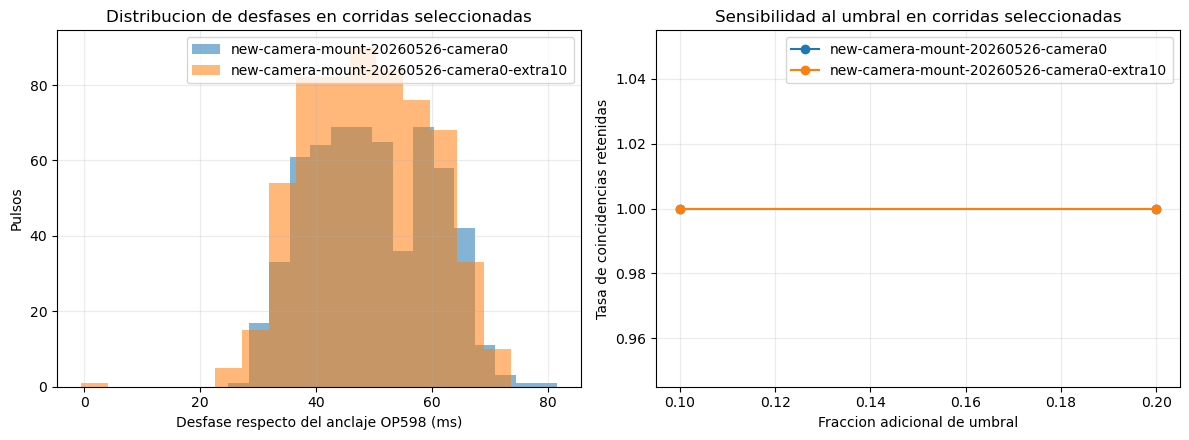

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
if not camera0_offsets.empty:
    for campaign, group in camera0_offsets.groupby('campaign'):
        axes[0].hist(group['offset_ms_plot'].dropna(), bins=16, alpha=0.55, label=campaign)
    axes[0].set_xlabel('Desfase respecto del anclaje OP598 (ms)')
    axes[0].set_ylabel('Pulsos')
    axes[0].set_title('Distribucion de desfases en corridas seleccionadas')
    axes[0].legend()
else:
    axes[0].set_title('Sin tabla de desfases disponible')

if not threshold_sensitivity.empty:
    for campaign, group in threshold_sensitivity.groupby('campaign'):
        axes[1].plot(group['threshold_delta_fraction'], group['retained_rate'], marker='o', label=campaign)
    axes[1].set_xlabel('Fraccion adicional de umbral')
    axes[1].set_ylabel('Tasa de coincidencias retenidas')
    axes[1].set_title('Sensibilidad al umbral en corridas seleccionadas')
    axes[1].legend()
else:
    axes[1].set_title('Sin sensibilidad de umbral disponible')
for ax in axes:
    ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

## Tecnica tipo astrofotografia: acumulacion y apilado

La analogia defendible con astrofotografia es la acumulacion de senal integrada. Si la senal es estacionaria y el ruido entre cuadros es independiente con varianza comparable, al promediar `N` cuadros la senal media se conserva y el ruido aleatorio disminuye como:

$$\sigma_{\bar Y} = \frac{\sigma}{\sqrt{N}}$$

Por lo tanto, la relacion senal-ruido ideal mejora como:

$$\mathrm{SNR}_{N} \approx \sqrt{N}\,\mathrm{SNR}_{1}$$

Limites en este experimento:

- La mejora `sqrt(N)` es ideal; no incluye ruido correlacionado, deriva de exposicion ni errores de seleccion.
- El promedio aumenta evidencia estadistica de una senal recurrente, pero no crea resolucion temporal sub-cuadro.
- Sin calibracion radiometrica, el resultado es comparativo y visual/estadistico, no fotometrico absoluto.

In [15]:
snr_gain = pd.DataFrame({'cuadros_apilados_N': [1, 2, 5, 10, 30, 60, 120]})
snr_gain['ganancia_snr_ideal_sqrt_N'] = np.sqrt(snr_gain['cuadros_apilados_N'])
display(snr_gain)

stacking_rows = []
for campaign in VALID_CAMPAIGNS:
    avg_path = ROOT / f'data/derived/reconstruction-camera0/{campaign}/avg_flash_frame.png'
    pooled_path = ROOT / f'data/derived/reconstruction-camera0/{campaign}/phase_averages/pooled/phase_+0_hit.png'
    stacking_rows.append({
        'campaign': campaign,
        'cuadro_promedio_destello_existe': avg_path.exists(),
        'promedio_fase_pooled_existe': pooled_path.exists(),
        'avg_flash_frame': str(avg_path.relative_to(ROOT)) if avg_path.exists() else None,
        'pooled_phase_average': str(pooled_path.relative_to(ROOT)) if pooled_path.exists() else None,
    })
stacking = pd.DataFrame(stacking_rows)
display(stacking)

,cuadros_apilados_N,ganancia_snr_ideal_sqrt_N
0,1,1.000000
1,2,1.414214
2,5,2.236068
3,10,3.162278
4,30,5.477226
5,60,7.745967
6,120,10.954451


,campaign,cuadro_promedio_destello_existe,promedio_fase_pooled_existe,avg_flash_frame,pooled_phase_average
0,new-camera-mount-20260526-camera0,True,True,data/derived/reconstruction-camera0/new-camera...,data/derived/reconstruction-camera0/new-camera...
1,new-camera-mount-20260526-camera0-extra10,True,True,data/derived/reconstruction-camera0/new-camera...,data/derived/reconstruction-camera0/new-camera...


**new-camera-mount-20260526-camera0 - cuadro promedio del destello**

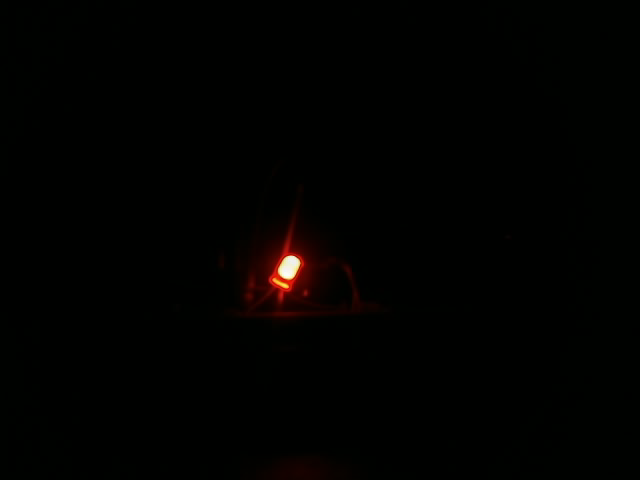

**new-camera-mount-20260526-camera0-extra10 - cuadro promedio del destello**

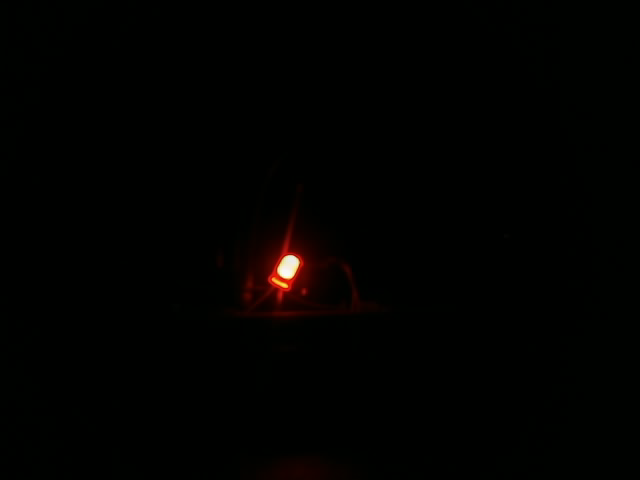

In [16]:
if display and Image:
    for _, row in stacking.iterrows():
        if row['cuadro_promedio_destello_existe']:
            display(Markdown(f"**{row['campaign']} - cuadro promedio del destello**"))
            display(Image(filename=str(ROOT / row['avg_flash_frame'])))

## Presupuesto de errores sistematicos

La tabla separa riesgos aleatorios y sistematicos. Cuando hay un numero defendible, se calcula desde los artefactos cargados; cuando no, se reporta como limitacion formal.

| Fuente | Tipo dominante | Direccion/riesgo | Mitigacion en este cuaderno | Limitacion residual |
|---|---|---|---|---|
| Cuantizacion temporal de camara | Sistematica/instrumental | Eventos dentro de un mismo cuadro no se ordenan temporalmente | Se reporta periodo y medio periodo de cuadro | No hay temporizacion sub-cuadro |
| Variabilidad de FPS | Aleatoria + sistematica | Cambia el periodo efectivo de cuadro | Se resume FPS medido en observaciones existentes | No reemplaza sincronizacion de hardware |
| Umbral de deteccion | Sistematica de procesamiento | Puede cambiar coincidencias retenidas | Se evalua sensibilidad a umbral mas estricto | No estima falsos positivos a umbral menor |
| Seleccion de corridas | Sistematica de analisis | Puede favorecer corridas con mejor cobertura | Se muestra seleccion y estadisticos por campana | No es muestreo aleatorio del montaje |
| Barridos agregados por duty | Limitacion de datos | Impiden inferencia pulso a pulso | Se usa binomial agregado y bracket | No hay reconstruccion por pulso |

In [17]:
systematic_budget_numeric = pd.DataFrame([
    {
        'fuente': 'Cuantizacion de cuadro de webcam',
        'tipo': 'sistematico/instrumental',
        'valor_numerico': half_frame_ms,
        'unidad': 'ms',
        'interpretacion': 'medio periodo de cuadro; cota de localizacion temporal por frame',
    },
    {
        'fuente': 'Variabilidad de FPS entre observaciones de intensidad',
        'tipo': 'aleatorio/sistematico',
        'valor_numerico': float(fps_summary['fps_desvio_estandar']),
        'unidad': 'FPS',
        'interpretacion': 'dispersion medida en artefactos existentes',
    },
    {
        'fuente': 'Intervalo de primera deteccion de intensidad',
        'tipo': 'limitacion de datos',
        'valor_numerico': threshold_bracket['primer_duty_con_deteccion'] - threshold_bracket['ultimo_duty_sin_deteccion'],
        'unidad': 'duty',
        'interpretacion': 'ancho entre ultimo duty sin deteccion y primero con deteccion',
    },
    {
        'fuente': 'Probabilidad maxima agregada observada',
        'tipo': 'limitacion de datos',
        'valor_numerico': max_supported_p,
        'unidad': 'probabilidad',
        'interpretacion': 'explica por que duty50/duty90 no son identificables',
    },
    {
        'fuente': 'Modelo ideal de ganancia por apilado',
        'tipo': 'supuesto de modelo',
        'valor_numerico': float(np.sqrt(60)),
        'unidad': 'factor SNR ideal',
        'interpretacion': 'ganancia teorica si N=60, ruido independiente y senal estacionaria',
    },
])
systematic_budget_numeric

,fuente,tipo,valor_numerico,unidad,interpretacion
0,Cuantizacion de cuadro de webcam,sistematico/instrumental,16.736237,ms,medio periodo de cuadro; cota de localizacion ...
1,Variabilidad de FPS entre observaciones de int...,aleatorio/sistematico,0.098861,FPS,dispersion medida en artefactos existentes
2,Intervalo de primera deteccion de intensidad,limitacion de datos,1.000000,duty,ancho entre ultimo duty sin deteccion y primer...
3,Probabilidad maxima agregada observada,limitacion de datos,0.133333,probabilidad,explica por que duty50/duty90 no son identific...
4,Modelo ideal de ganancia por apilado,supuesto de modelo,7.745967,factor SNR ideal,"ganancia teorica si N=60, ruido independiente ..."


## Formulas de propagacion y ejemplos numericos

| Cantidad | Formula | Interpretacion |
|---|---|---|
| Estimador binomial | `p_hat = k/n` | Fraccion de pulsos esperados con deteccion acotada |
| Periodo de cuadro | `T_f = 1000/FPS` | Separacion temporal media entre cuadros |
| Incertidumbre de medio cuadro | `u_f = T_f/2` | Cota natural por cuantizacion de cuadro |
| Combinacion independiente | `u_c = sqrt(sum(u_i^2))` | Propagacion conservadora de terminos no correlacionados |
| Ganancia ideal por apilado | `SNR_N/SNR_1 = sqrt(N)` | Mejora esperada si ruido independiente y senal estacionaria |

In [18]:
examples = pd.DataFrame([
    {
        'ejemplo': 'primer duty de intensidad no nulo',
        'valor': threshold_bracket['primer_duty_con_deteccion'],
        'unidad': 'duty',
        'significado': 'primer punto con deteccion agregada en barridos validos',
    },
    {
        'ejemplo': 'termino temporal de medio cuadro de webcam',
        'valor': half_frame_ms,
        'unidad': 'ms',
        'significado': 'limite de cuantizacion temporal por frame',
    },
    {
        'ejemplo': 'ganancia SNR ideal para 60 cuadros apilados',
        'valor': float(np.sqrt(60)),
        'unidad': 'factor',
        'significado': 'modelo ideal, no medicion fotometrica calibrada',
    },
])
examples

,ejemplo,valor,unidad,significado
0,primer duty de intensidad no nulo,4.000000,duty,primer punto con deteccion agregada en barrido...
1,termino temporal de medio cuadro de webcam,16.736237,ms,limite de cuantizacion temporal por frame
2,ganancia SNR ideal para 60 cuadros apilados,7.745967,factor,"modelo ideal, no medicion fotometrica calibrada"


## Conclusiones finales y limitaciones

### Conclusiones defendibles

- Los barridos validos agregados por duty muestran una transicion practica entre duty 3 sin detecciones y duty 4 con detecciones.
- La probabilidad agregada maxima observada en esos barridos no alcanza 0.50; por eso `duty50` y `duty90` no son estimables con esta evidencia.
- El limite temporal principal esta dado por el periodo de cuadro de la webcam, aproximadamente 33 ms para 30 FPS, con incertidumbre natural de medio cuadro.
- Las reconstrucciones validas de camara0 respaldan promedios estadisticos y analisis de coincidencias en corridas seleccionadas.
- El apilado puede mejorar SNR de manera ideal como `sqrt(N)`, pero solo bajo supuestos que aqui se declaran explicitamente.

### Limitaciones no negociables

- No hay fotometria calibrada.
- No hay temporizacion sub-cuadro.
- No hay inferencia pulso a pulso en los barridos nuevos de intensidad.
- No se usan datos de la campana `new-camera-mount-20260526-phase4` ni de camara indice 2.
- Las conclusiones dependen de artefactos offline ya generados; no se reejecuta adquisicion ni hardware.